In [1]:
import torch 
from torch import nn
import pandas as pd 
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
doc_file = pd.read_csv("./dataset/metadata.csv")
doc_file

,image_id,split,image_souce_url,label_source_url,tiff_image_path,tif_label_path,png_image_path,png_label_path
0,10078660_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078660_15.tiff,tiff/train_labels/10078660_15.tif,png/train/10078660_15.png,png/train_labels/10078660_15.png
1,10078675_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078675_15.tiff,tiff/train_labels/10078675_15.tif,png/train/10078675_15.png,png/train_labels/10078675_15.png
2,10078690_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078690_15.tiff,tiff/train_labels/10078690_15.tif,png/train/10078690_15.png,png/train_labels/10078690_15.png
3,10078705_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078705_15.tiff,tiff/train_labels/10078705_15.tif,png/train/10078705_15.png,png/train_labels/10078705_15.png
4,10078720_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078720_15.tiff,tiff/train_labels/10078720_15.tif,png/train/10078720_15.png,png/train_labels/10078720_15.png
...,...,...,...,...,...,...,...,...
1166,25079170_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/25079170_15.tiff,tiff/test_labels/25079170_15.tif,png/test/25079170_15.png,png/test_labels/25079170_15.png
1167,26278720_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26278720_15.tiff,tiff/test_labels/26278720_15.tif,png/test/26278720_15.png,png/test_labels/26278720_15.png
1168,26428735_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26428735_15.tiff,tiff/test_labels/26428735_15.tif,png/test/26428735_15.png,png/test_labels/26428735_15.png
1169,26578720_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26578720_15.tiff,tiff/test_labels/26578720_15.tif,png/test/26578720_15.png,png/test_labels/26578720_15.png


In [3]:
train_files = doc_file[doc_file["split"] == "train"]["tiff_image_path"]
train_label_files = doc_file[doc_file["split"] == "train"]["tif_label_path"]
train_files,train_label_files

(0       tiff/train/10078660_15.tiff
 1       tiff/train/10078675_15.tiff
 2       tiff/train/10078690_15.tiff
 3       tiff/train/10078705_15.tiff
 4       tiff/train/10078720_15.tiff
                    ...             
 1103    tiff/train/27028705_15.tiff
 1104    tiff/train/27028720_15.tiff
 1105    tiff/train/27178705_15.tiff
 1106    tiff/train/99238660_15.tiff
 1107    tiff/train/99238675_15.tiff
 Name: tiff_image_path, Length: 1108, dtype: object,
 0       tiff/train_labels/10078660_15.tif
 1       tiff/train_labels/10078675_15.tif
 2       tiff/train_labels/10078690_15.tif
 3       tiff/train_labels/10078705_15.tif
 4       tiff/train_labels/10078720_15.tif
                       ...                
 1103    tiff/train_labels/27028705_15.tif
 1104    tiff/train_labels/27028720_15.tif
 1105    tiff/train_labels/27178705_15.tif
 1106    tiff/train_labels/99238660_15.tif
 1107    tiff/train_labels/99238675_15.tif
 Name: tif_label_path, Length: 1108, dtype: object)

In [4]:
import os

train_files = [os.path.join("./dataset/",f) for f in train_files]
train_label_files = [os.path.join("./dataset/",f) for f in train_label_files]

In [5]:
train_files = [Image.open(f).resize((256,256)) for f in train_files]
train_label_files = [Image.open(f).resize((256,256)) for f in train_label_files]

In [6]:
# for f in train_files:
#     if f.size != (1500,1500):
#         print(f.size)

# for f in train_label_files:
#     if f.size != (1500,1500):
#         print(f.size)

All the training files are of same size (1500,1500) (converted to (256,256))

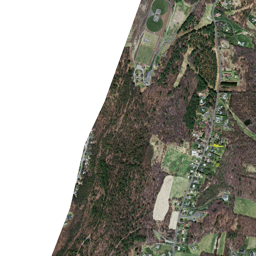

In [7]:
train_files[4]

The image is corrupted and partial infomation is available.
Firstly to avoid these to trouble the model, I will mask the label such that the blank implies no roads.

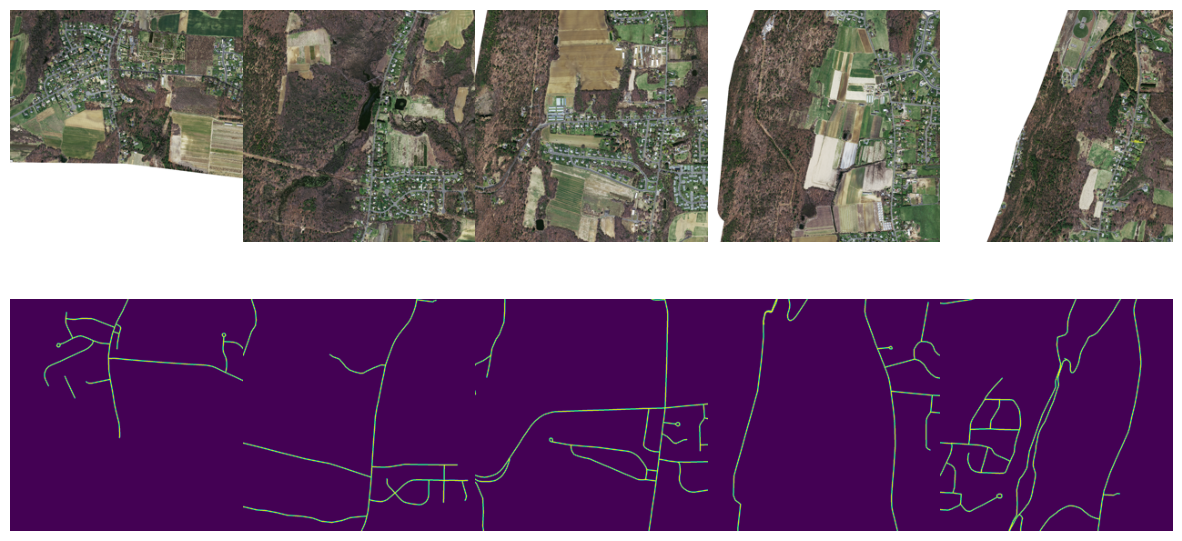

In [8]:

plt.figure(figsize=(15,15))
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.axis("off")
    plt.imshow(train_files[i])
    plt.subplot(1,5,i+1)
    plt.axis("off")
    plt.imshow(train_label_files[i])

The annotation are human made and thus some road look way obivious and some hard to see. Some lines also seem to be road but there aren't labeled implying that all the path are not road. Thus we have to in particular select the official marked roads only which may confuuse the model. 

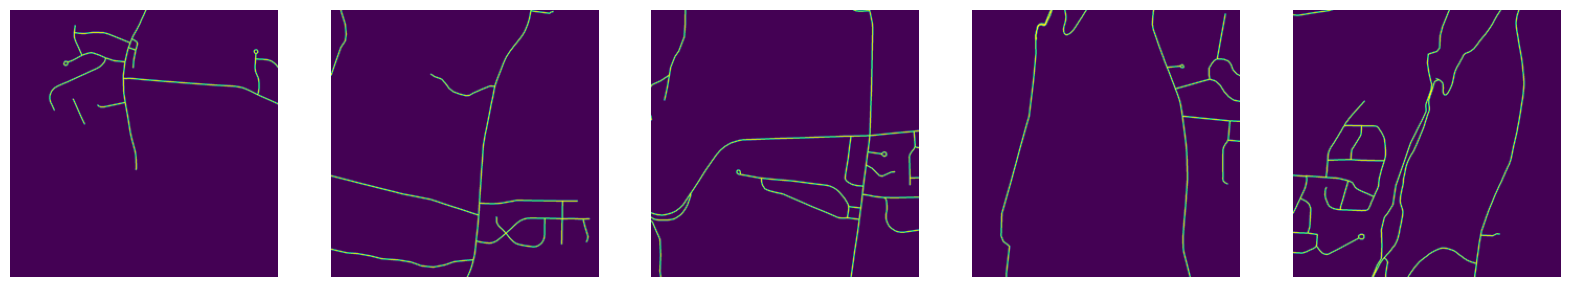

In [9]:

plt.figure(figsize=(20,20))
plt.tight_layout()
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.axis("off")
    plt.imshow(train_label_files[i])

In [10]:
np.asarray(train_files[0])[:2,:2]

array([[[99, 83, 73],
        [62, 82, 50]],

       [[99, 83, 73],
        [88, 85, 65]]], dtype=uint8)

the image is in rgb format.

In [11]:
from torch.utils.data import DataLoader,Dataset

class RoadDataset(Dataset):
    def __init__(self, inputs, labels, transform, label_transform):
        self.x = [transform(i) for i in inputs]
        self.y = [label_transform(self.x[i],labels[i]) for i in range(len(labels))]

    def __len__(self):
        return len(self.y)

    def __getitem__(self,idx):
        return self.x[idx], self.y[idx]
        
    

In [12]:
def input_transform(x:Image):
    x = np.asarray(x,dtype=np.float32)/255.0
    x = torch.tensor(x).transpose(-1,-2).transpose(-2,-3)
    return x

def label_transform(x:torch.Tensor, y:Image):
    y = np.asarray(y,dtype=np.float32)/255.0
    y = torch.tensor(y)
    
    x_ = x.mean(axis=-3)
    x_ = torch.where(x_ == 0, 0, 1)
    return y*x_
    

In [13]:
train_dataset = RoadDataset(train_files,train_label_files,input_transform,label_transform)
train_size = len(train_dataset)

In [14]:
valid_files = doc_file[doc_file["split"] == "val"]["tiff_image_path"]
valid_label_files = doc_file[doc_file["split"] == "val"]["tif_label_path"]

valid_files = [Image.open(os.path.join("./dataset/",f)).resize((256,256)) for f in valid_files]
valid_label_files = [Image.open(os.path.join("./dataset/",f)).resize((256,256)) for f in valid_label_files]

valid_dataset = RoadDataset(valid_files,valid_label_files,input_transform,label_transform)
valid_size = len(valid_dataset)

In [15]:
test_files = doc_file[doc_file["split"] == "test"]["tiff_image_path"]
test_label_files = doc_file[doc_file["split"] == "test"]["tif_label_path"]

test_files = [Image.open(os.path.join("./dataset/",f)).resize((256,256)) for f in test_files]
test_label_files = [Image.open(os.path.join("./dataset/",f)).resize((256,256)) for f in test_label_files]

test_dataset = RoadDataset(test_files,test_label_files,input_transform,label_transform)
test_size = len(test_dataset)

In [1]:
class RoadPredictor(nn.Module):
    def __init__(self,device):
        super().__init__()
        
        self.convs = nn.ModuleList([nn.Conv2d(3,5,5).to(device),nn.Conv2d(5,4,5).to(device),nn.Conv2d(4,3,5).to(device), nn.Conv2d(3+4,3,5).to(device), nn.Conv2d(3+5,3,5).to(device)])
        self.maxpool = nn.ModuleList([nn.MaxPool2d(2).to(device) for i in range(2)])
        self.upconvs = nn.ModuleList([nn.ConvTranspose2d(3,3,2,stride=2).to(device) for i in range(2)])
        self.upconvs.append(nn.ConvTranspose2d(3,1,2,stride=2).to(device))
        self.gaps = nn.ModuleList([nn.AdaptiveAvgPool2d((114,114)).to(device), nn.AdaptiveAvgPool2d((220,220)).to(device),nn.AdaptiveAvgPool2d((256,256)).to(device)])

    def forward(self,x):
        x1 = self.convs[0](x)
        x2 = self.maxpool[0](x1)
        x3 = self.convs[1](x2)
        x4 = self.maxpool[1](x3)
        x5 = self.convs[2](x4)
        x6 = self.upconvs[0](x5)
        x6 = torch.concat([x6,self.gaps[0](x3)], dim=1)
        x7 = self.convs[3](x6)
        x8 = self.upconvs[1](x7)
        x8 = torch.concat([x8,self.gaps[1](x1)], dim=1)
        x8 = self.convs[4](x8)
        x9 = self.upconvs[2](x8)
        x9 = self.gaps[2](x9)
        return x9

NameError: name 'nn' is not defined

In [ ]:
train_data = DataLoader(train_dataset,batch_size=16)
valid_data = DataLoader(valid_dataset,batch_size=4096)
test_data = DataLoader(test_dataset,batch_size=4096)

max_epochs = 100
learning_rate = 3e-3

device = "cuda:0" if torch.cuda.is_available() else "cpu"
#device = "cpu"
model = RoadPredictor(device)
model.to(device)
loss_fn = nn.MSELoss()

opt = torch.optim.AdamW(model.parameters(),lr = learning_rate)
accuracy = []
losses = []
model.train()
for i in range(max_epochs):
    s = 0
    for (x,y) in train_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        losses.append(loss.item())
        loss.backward()
        s+=loss.item()
        opt.step()
        opt.zero_grad()
    with torch.no_grad():
        total = 0
        for (x,y) in valid_data:
            y = y.to(device).reshape((-1,256*256))
            x = x.to(device)
            pred = model(x)
            total += ((y - pred)**2).reshape(-1).sum().cpu().item() 
            accuracy.append(total/valid_size/256/256) 
        if (i%10 == 0):
            print(accuracy[-1])

torch.save(model.state_dict(), f"./model_parameter.trhmodel")
with open("log.txt","w") as f:
    f.write("\n".join(list(map(str,accuracy))))
with open("log2.txt","w") as f:
    f.write("\n".join(list(map(str,losses))))


In [ ]:
plt.plot(accuracy)

In [ ]:
model.eval()

total = 0
total2 = 0
total3 = 0
total4 = 0
avg =0
with torch.no_grad():
    for (x,y) in test_data:
        y = y.to(device)
        x = x.to(device)
        pred = model(x).transpose(-1,-2)
        pred = torch.softmax(pred,dim=-1)
        pred = torch.argmax(pred,dim=-1)
        z = (y == pred).reshape(-1)
        total+=z.sum()
        z = z.reshape(-1,10)
        total2 += torch.where(torch.sum(z,dim = -1) == 10, 1,0).sum()
        total3 += torch.where(abs(torch.sum(z,dim = -1)-10)<=1, 1,0).sum()
        total4 += torch.where(abs(torch.sum(z,dim = -1)-10)<=2, 1,0).sum()
        avg += abs(torch.sum(z,dim = -1)-10).sum()

print("Test Accuracy (%):",total/test_size/10*100)
print("Full sequence correct (%):",total2/test_size*100)
print("Atmost 1 incorect sequence correct (%):",total3/test_size*100)
print("Atmost 2 incorect sequence correct (%):",total4/test_size*100)
print("Average no of rank predicted incorect in a sequence :",avg/test_size)

with torch.no_grad():
    for i in range(4,50,5):
        (x,y) = test_dataset[i]
        x = x.to(device).reshape(1,10)
        pred = model(x).transpose(-1,-2)
        pred = pred.reshape(10,10).cpu()
        pred = torch.argmax(pred,dim=-1).reshape(-1)
        print(f"{i+1} testcase")
        print("x : ",x.cpu().numpy())
        print("pred : ",pred.numpy())
        print("true : ",y)
